# Maskinlæring for Aksjedata

Normalt når man skal jobbe med maskinlæring følger man følgende prosess:  
Cleaning / Preprossesering -> EDA (Exploratory Data Analysis) -> Feature Engineering -> Trening -> Evaluering av modell  

<br>

Vi er nå på Trening av maskinlæringsmodellen. Denne notebooken gir et eksempel på Klassifikasjon

## Eksempler på ulike modeller for klassifikasjon

#### Logistic Regression

En klassifikasjonsmodell som estimerer sannsynligheten for at en observasjon tilhører en bestemt klasse.

Brukes ofte som et enkelt og tolkbart utgangspunkt.

<br>

#### Random Forest

En modell som kombinerer mange beslutningstrær for å forbedre prediksjonskvaliteten.

Robust mot støy og mye brukt på tabulære data.

<br>

#### Gradient Boosting

En modell som bygger flere svake modeller sekvensielt for å redusere feil.

Populær innen finans og maskinlæringskonkurranser.

<br>

#### XGBoost

En optimalisert implementasjon av Gradient Boosting.

Kjent for høy ytelse på strukturerte datasett.

<br>

#### CatBoost

CatBoost er en Gradient Boosting-modell som er spesielt utviklet for tabulære datasett og håndterer kategoriske variabler effektivt.

Brukes ofte til:

- Klassifikasjon
- Regresjon
- Prediksjon på markedsdata

<br>

#### LightGBM

LightGBM er en Gradient Boosting-modell som er optimalisert for hastighet og skalerbarhet på store datasett.

Brukes ofte til:

- Klassifikasjon
- Regresjon
- Finansiell modellering

## Importering og Loading av Data

In [70]:
# Importering av biblioteker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, brier_score_loss, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit

In [71]:
df = pd.read_csv("df.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 20 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   open         239 non-null    float64
 1   high         239 non-null    float64
 2   low          239 non-null    float64
 3   close        239 non-null    float64
 4   volume       239 non-null    float64
 5   trade_count  239 non-null    float64
 6   vwap         239 non-null    float64
 7   sma5         239 non-null    float64
 8   sma50        239 non-null    float64
 9   sma100       239 non-null    float64
 10  ema20        239 non-null    float64
 11  rsi14        239 non-null    float64
 12  macd         239 non-null    float64
 13  upperBB      239 non-null    float64
 14  lowerBB      239 non-null    float64
 15  ATR14        239 non-null    float64
 16  momentum     239 non-null    float64
 17  deviation    239 non-null    float64
 18  zscore       239 non-null    float64
 19  target       239 no

## Feature Engineering / Selection

Vi skal nå gjøre de samme feature engineering og selection metodene som vi gjorde i forrige notebook, men denne gangen splitter vi dataen i trening- og testsett. Dette gjør vi for å unngå **data leakage** og Look-Ahead-Bias. Altså at modellen får tilgang på informasjon om fremtiden.

**Data leakage** er når modellen får tilgang til informasjon den ikke ville hatt tilgjengelig når den skal gjøre prediksjoner i praksis. Dette gir kunstig gode resultater og et misvisende bilde av modellens ytelse.

In [72]:
# Splitting
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

X_train = train.drop(columns=["target"])
y_train = train["target"]

X_test = test.drop(columns=["target"])
y_test = test["target"]

### Selection

In [73]:
varians = X_train.var(numeric_only = True)
top_features = varians.nlargest(3).index.tolist()

X_test_selected = X_test[top_features]
X_train_selected = X_train[top_features]

### PCA

In [74]:
scalar = StandardScaler()

X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

pca = PCA(n_components = 0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

## Trening og Evaluation

### Selection

In [75]:
model_selected = LogisticRegression()

model_selected.fit(X_train_selected, y_train)

y_pred_selected = model_selected.predict(X_test_selected)
y_proba_selected = model_selected.predict_proba(X_test_selected)

print(f"ROC-AUC Score = {roc_auc_score(y_test, y_pred_selected)}")
print(f"Brier Score = {brier_score_loss(y_test, y_proba_selected)}")
print(classification_report(y_test, y_pred_selected))

ROC-AUC Score = 0.5
Brier Score = 0.2488499989507126
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        22
           1       0.54      1.00      0.70        26

    accuracy                           0.54        48
   macro avg       0.27      0.50      0.35        48
weighted avg       0.29      0.54      0.38        48



c:\Users\milad\Desktop\EikLab x FinTech\Notebooks for videoserien\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\milad\Desktop\EikLab x FinTech\Notebooks for videoserien\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\milad\Desktop\EikLab x FinTech\Notebooks for videoserien\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

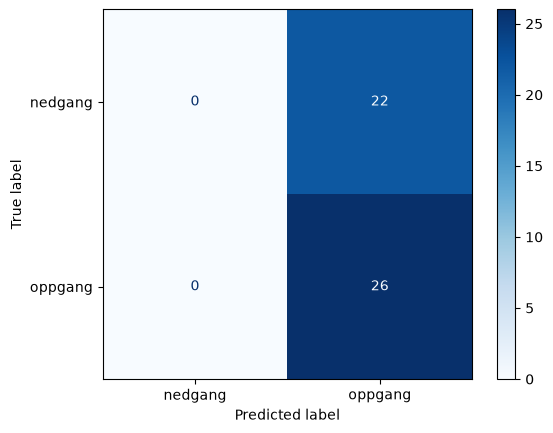

In [76]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_selected, display_labels=["nedgang", "oppgang"], cmap = "Blues")
plt.show()

### PCA

In [77]:
model_pca = LogisticRegression()

model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)
y_proba_pca = model_pca.predict_proba(X_test_pca)

print(f"ROC-AUC Score = {roc_auc_score(y_test, y_pred_pca)}")
print(f"Brier Score = {brier_score_loss(y_test, y_proba_pca)}")
print(classification_report(y_test, y_pred_pca))

ROC-AUC Score = 0.4597902097902098
Brier Score = 0.27610255087677693
              precision    recall  f1-score   support

           0       0.43      0.73      0.54        22
           1       0.45      0.19      0.27        26

    accuracy                           0.44        48
   macro avg       0.44      0.46      0.41        48
weighted avg       0.44      0.44      0.39        48



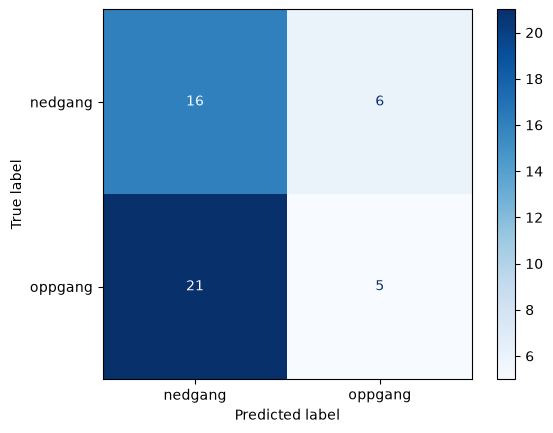

In [78]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_pca, display_labels=["nedgang", "oppgang"], cmap = "Blues")

plt.show()

### Litt om evaluasjons-nøkkeltallene

#### Accuracy

Andelen korrekte prediksjoner gjort av modellen:

$$
Accuracy =
\frac{TP + TN}
{TP + TN + FP + FN}
$$

**Hvorfor er Accuracy viktig ved predikasjon av aksjer?**

Accuracy gir et overordnet mål på hvor ofte modellen predikerer riktig retning i markedet. Dersom modellen skal klassifisere om en aksje vil stige eller falle, viser Accuracy hvor stor andel av disse beslutningene som er korrekte.

Samtidig kan Accuracy være misvisende dersom datasettet er ubalansert. Hvis markedet for eksempel stiger 70 % av tiden, kan en modell som alltid predikerer "oppgang" oppnå høy Accuracy uten å ha reell prediktiv verdi. Derfor bør Accuracy vurderes sammen med andre evalueringsmål.

<br>

#### Precision

Andelen positive prediksjoner som faktisk var positive:

$$
Precision =
\frac{TP}
{TP + FP}
$$

**Hvorfor er Precision viktig ved predikasjon av aksjer?**

Precision beskriver hvor pålitelige modellens kjøpssignaler er. En høy Precision innebærer at når modellen predikerer at en aksje vil stige, skjer dette ofte i praksis.

Dette er særlig viktig dersom falske positive signaler er kostbare, ettersom hver feilaktige kjøpsbeslutning kan føre til tap, transaksjonskostnader og redusert avkastning.

<br>

#### Recall

Andelen faktiske positive observasjoner som modellen klarte å identifisere:

$$
Recall =
\frac{TP}
{TP + FN}
$$

**Hvorfor er Recall viktig ved predikasjon av aksjer?**

Recall måler hvor godt modellen fanger opp de faktiske mulighetene i markedet. En høy Recall betyr at modellen identifiserer mange av periodene hvor aksjen faktisk stiger.

Dette kan være verdifullt dersom målet er å utnytte flest mulig lønnsomme investeringsmuligheter. Ulempen er at Recall ofte øker på bekostning av flere falske positive signaler.

<br>

#### F1-Score

Det harmoniske gjennomsnittet av Precision og Recall.

Brukes når begge målene er viktige:

$$
F1 =
2 \cdot
\frac{
Precision \cdot Recall
}{
Precision + Recall
}
$$

**Hvorfor er F1-Score viktig ved predikasjon av aksjer?**

F1-Score balanserer Precision og Recall i ett samlet mål. Dette er nyttig når både kvaliteten på kjøpssignalene og evnen til å oppdage reelle markedsmuligheter er viktige.

Innen aksjeprediksjon gir F1-Score derfor et mer nyansert bilde av modellens prestasjon enn Accuracy alene, spesielt ved ubalanserte datasett.

<br>

#### Brier Score

Måler kvaliteten på sannsynlighetsprediksjoner.

Lavere verdi indikerer bedre kalibrerte sannsynligheter:

$$
Brier =
\frac{1}{N}
\sum_{i=1}^{N}
(p_i - y_i)^2
$$

der:

- $N$ er antall observasjoner,
- $p_i$ er modellens predikerte sannsynlighet,
- $y_i$ er den faktiske observasjonen (0 eller 1).

**Hvorfor er Brier Score viktig ved predikasjon av aksjer?**

I finans er det ofte ikke nok å vite hvilken retning modellen predikerer; man ønsker også å vite hvor sikker modellen er. Brier Score evaluerer hvor godt disse sannsynlighetene samsvarer med de faktiske utfallene.

Godt kalibrerte sannsynligheter kan brukes i risikostyring, porteføljeallokering og beslutninger om hvor store posisjoner som bør tas.

<br>

#### AUC-ROC

AUC (Area Under the Curve) er arealet under ROC-kurven (Receiver Operating Characteristic), som viser forholdet mellom sann sann positiv-rate og falsk positiv-rate ved ulike klassifiseringsterskler.

ROC-kurven er definert ved:

$$
TPR =
\frac{TP}{TP + FN}
$$

$$
FPR =
\frac{FP}{FP + TN}
$$

AUC beregnes som arealet under denne kurven:

$$
AUC = \int_{0}^{1} TPR(FPR)\,d(FPR)
$$

Verdier ligger mellom 0 og 1:

- $AUC = 0.5$ tilsvarer tilfeldig gjetning,
- $AUC > 0.5$ indikerer prediktiv evne,
- $AUC = 1.0$ representerer perfekt separasjon mellom klassene.

**Hvorfor er AUC-ROC viktig ved predikasjon av aksjer?**

AUC-ROC måler modellens evne til å skille mellom perioder med oppgang og nedgang uavhengig av valgt beslutningsterskel. Dette gjør metrikken spesielt nyttig når man ønsker å sammenligne ulike modeller før man bestemmer hvilken sannsynlighetsterskel som skal utløse kjøp eller salg.

En høy AUC indikerer at modellen generelt rangerer observasjoner korrekt ved å tilordne høyere sannsynlighet til faktiske oppgangsperioder enn til nedgangsperioder. Dette er verdifullt i finansielle anvendelser, hvor beslutningsregler og risikotoleranse ofte varierer mellom investorer og strategier.

### Predikasjon

Selection ga et bedre resultat, derfor ser vi nærmere på predikasjonen modellen ga.

In [79]:
print(y_pred_selected[-1])
print(y_proba_pca[-1])

1
[0.21495211 0.78504789]


**Modellen predikerete at apple aksjen skal stige med 78.5% sannsynlighet når markedet åpner igjen.**

Eksempel på strategy:  
Kjøp når modellen predikerer 1,  
Selg når modellen predikerer 0

## Overfitting

Overfitting er når en modell lærer treningsdataene for godt, inkludert støy og tilfeldige mønstre, slik at den presterer dårlig på nye, ukjente data. La oss se på selection dataframen.

In [80]:
# Prediksjoner på treningssettet
y_pred_train = model_selected.predict(X_train_selected)
y_proba_train = model_selected.predict_proba(X_train_selected)[:, 1]

# Prediksjoner på testsettet
y_pred_test = model_selected.predict(X_test_selected)
y_proba_test = model_selected.predict_proba(X_test_selected)[:, 1]

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy :", accuracy_score(y_test, y_pred_test))

print("Train AUC:", roc_auc_score(y_train, y_proba_train))
print("Test AUC :", roc_auc_score(y_test, y_proba_test))

Train Accuracy: 0.5235602094240838
Test Accuracy : 0.5416666666666666
Train AUC: 0.537032967032967
Test AUC : 0.4930069930069931


In [81]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

target
1    0.52356
0    0.47644
Name: proportion, dtype: float64
target
1    0.541667
0    0.458333
Name: proportion, dtype: float64


In [82]:
print(np.unique(y_pred_train, return_counts=True))
print(np.unique(y_pred_test, return_counts=True))

(array([0, 1]), array([  2, 189]))
(array([1]), array([48]))


Analysen viser ingen tydelige tegn til overfitting, ettersom prestasjonen på trenings- og testdata er relativt lik. Modellen predikerer imidlertid nesten utelukkende majoritetsklassen (klasse 1), noe som resulterer i en Accuracy på omtrent 54 %, tilsvarende andelen positive observasjoner i datasettet. AUC-verdier nær 0,5 indikerer videre at modellen ikke klarer å skille mellom klassene bedre enn tilfeldig gjetning. Resultatene tyder derfor på at modellen ikke har identifisert et robust prediktivt signal i dataene.

## Walk-Forward-Testing: TimeSeriesSplit

Ved predikasjon av aksjekurser er dataene organisert kronologisk, hvor observasjoner fra fortiden brukes til å predikere fremtidige hendelser. I slike tilfeller er det ikke hensiktsmessig å benytte tilfeldig splitting av datasettet, da dette kan føre til at modellen får *look-ahead bias* og kan gi urealistisk gode resultater.

For å unngå dette benyttes TimeSeriesSplit, som bevarer den tidsmessige rekkefølgen i dataene. Metoden trener modellen på historiske observasjoner og evaluerer den på senere perioder. Treningssettet utvides gradvis for hver iterasjon, mens testsettet alltid består av observasjoner som kommer etter treningsdataene i tid.


In [83]:
tscv = TimeSeriesSplit(n_splits = 5)

X = None
y = None
X = df.drop(columns = ["target"])
y = df["target"]

scaler = StandardScaler()

aucs = []
accs = []

for train_i, test_i in tscv.split(X):
    X_train = X.iloc[train_i]
    X_test = X.iloc[test_i]

    y_train = y.iloc[train_i]
    y_test = y.iloc[test_i]

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model = LogisticRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Evaluering
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    accs.append(acc)
    aucs.append(auc)

    print(f"Accuracy: {acc:.3f}")
    print(f"AUC: {auc:.3f}")
    print("-" * 30)

print("\nGjennomsnitt:")
print(f"Accuracy: {np.mean(accs):.3f}")
print(f"AUC: {np.mean(aucs):.3f}")

Accuracy: 0.538
AUC: 0.497
------------------------------
Accuracy: 0.538
AUC: 0.626
------------------------------
Accuracy: 0.487
AUC: 0.576
------------------------------
Accuracy: 0.513
AUC: 0.526
------------------------------
Accuracy: 0.462
AUC: 0.463
------------------------------

Gjennomsnitt:
Accuracy: 0.508
AUC: 0.538


c:\Users\milad\Desktop\EikLab x FinTech\Notebooks for videoserien\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\milad\Desktop\EikLab x FinTech\Notebooks for videoserien\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the d